In [21]:
%pip install seaborn
%pip install xgboost

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report ,confusion_matrix  
from imblearn.over_sampling import RandomOverSampler


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [22]:
# Load the dataset
df = pd.read_csv("synthetic_diabetes_data.csv")
df.head(5)


,glucose_mg_dl,carbs_last_meal_grams,recent_insulin,symptoms,condition
0,336.6,106,No,"thirst,nausea,increased_breathing,fatigue",DKA
1,138.7,56,Yes,NaN,Normal
2,209.8,88,Yes,"severe_thirst,frequent_urination,fatigue",Hyperglycemia
3,29.3,19,Yes,"disorientation,weakness,cold_sweats",Hypoglycemia
4,389.8,97,No,"severe_thirst,frequent_urination,fatigue",Hyperglycemia


In [23]:
df['symptoms'] = df['symptoms'].fillna('None')


In [24]:
# Check for missing values
df.isnull().sum()


glucose_mg_dl            0
carbs_last_meal_grams    0
recent_insulin           0
symptoms                 0
condition                0
dtype: int64

In [25]:
# Get a statistical summary of the dataset
df.describe()


,glucose_mg_dl,carbs_last_meal_grams
count,2000.000000,2000.000000
mean,218.557050,67.338500
std,163.436542,38.626972
min,20.000000,0.000000
25%,69.975000,36.750000
50%,170.000000,65.000000
75%,346.000000,98.250000
max,598.900000,149.000000


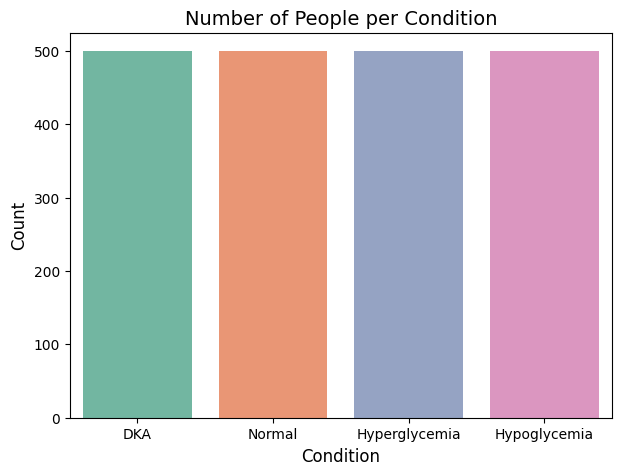

In [26]:
plt.figure(figsize=(7, 5))
# Assign the x variable to both x and hue to avoid the warning
sns.countplot(x="condition", hue="condition", data=df, palette="Set2", legend=False)
plt.title("Number of People per Condition", fontsize=14)
plt.xlabel("Condition", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [27]:
# Display column names
print(df.columns)


Index(['glucose_mg_dl', 'carbs_last_meal_grams', 'recent_insulin', 'symptoms',
       'condition'],
      dtype='object')


In [28]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop("condition", axis=1)
y = df["condition"]

# Add stratify=y to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y 
)

# Verify the split is balanced
print("Training set distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation set distribution:")
print(y_val.value_counts().sort_index())

Training set distribution:
condition
DKA              400
Hyperglycemia    400
Hypoglycemia     400
Normal           400
Name: count, dtype: int64

Validation set distribution:
condition
DKA              100
Hyperglycemia    100
Hypoglycemia     100
Normal           100
Name: count, dtype: int64


In [29]:
# Convert categorical features to numeric
X_train = X_train.apply(lambda col: pd.factorize(col)[0] if col.dtype == 'object' else col)
X_val = X_val.apply(lambda col: pd.factorize(col)[0] if col.dtype == 'object' else col)


In [30]:

# Initialize model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict and evaluate

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Accuracy: 0.8275

Classification Report:
                precision    recall  f1-score   support

          DKA       0.61      0.83      0.71       100
Hyperglycemia       0.74      0.48      0.58       100
 Hypoglycemia       1.00      1.00      1.00       100
       Normal       1.00      1.00      1.00       100

     accuracy                           0.83       400
    macro avg       0.84      0.83      0.82       400
 weighted avg       0.84      0.83      0.82       400


Confusion Matrix:
 [[ 83  17   0   0]
 [ 52  48   0   0]
 [  0   0 100   0]
 [  0   0   0 100]]


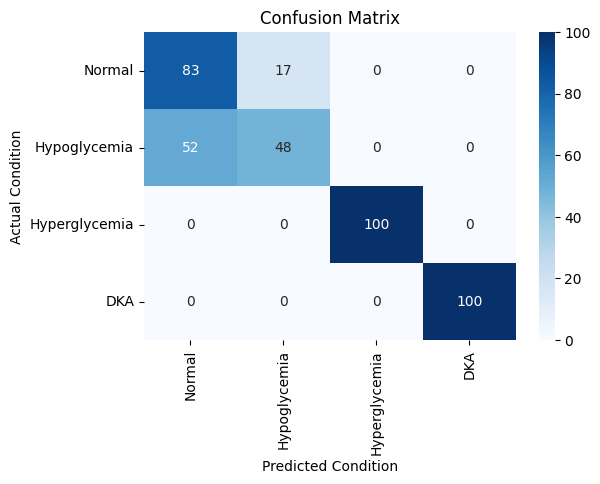

In [32]:

# Define readable labels for your conditions
labels = ["Normal", "Hypoglycemia", "Hyperglycemia", "DKA"]

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot with labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Condition')
plt.ylabel('Actual Condition')
plt.show()


In [33]:
df_real = pd.read_csv("diabetes_dataset.csv")
# Show the first few rows
df_real.head()


,patient_id,glucose_mg_dl,carbs_last_meal_grams,recent_insulin,symptoms,condition,severity
0,HYPER_010,343.2,138.0,No,"extreme_fatigue,polyuria,blurred_vision",Hyperglycemia,Severe
1,HYPER_081,207.4,96.0,No,"thirst,polyuria,mild_fatigue",Hyperglycemia,Moderate
2,NORM_034,78.4,54.0,No,NaN,Normal,NaN
3,HYPER_011,381.7,108.0,No,"excessive_thirst,weakness,frequent_urination",Hyperglycemia,Severe
4,NORM_094,76.6,67.0,Yes,NaN,Normal,NaN


In [34]:
X_real = df_real.drop("condition", axis=1)
y_real = df_real["condition"]


In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X_real["symptoms"] = label_encoder.fit_transform(X_real["symptoms"])


In [36]:
print(df_real.columns.tolist())


['patient_id', 'glucose_mg_dl', 'carbs_last_meal_grams', 'recent_insulin', 'symptoms', 'condition', 'severity']


In [37]:
# Drop only existing columns
cols_to_drop = ["patient_id", "condition", "severity"]
df_real = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("\nAfter dropping extra columns:\n")
print(df_real.head())

print("\nRemaining columns:\n", df_real.columns.tolist())



After dropping extra columns:

   glucose_mg_dl  carbs_last_meal_grams recent_insulin  \
0          336.6                    106             No   
1          138.7                     56            Yes   
2          209.8                     88            Yes   
3           29.3                     19            Yes   
4          389.8                     97             No   

                                    symptoms  
0  thirst,nausea,increased_breathing,fatigue  
1                                       None  
2   severe_thirst,frequent_urination,fatigue  
3        disorientation,weakness,cold_sweats  
4   severe_thirst,frequent_urination,fatigue  

Remaining columns:
 ['glucose_mg_dl', 'carbs_last_meal_grams', 'recent_insulin', 'symptoms']


In [38]:
df_real["recent_insulin"] = df_real["recent_insulin"].map({"Yes": 1, "No": 0})


In [39]:
from sklearn.preprocessing import LabelEncoder

# Fit on training data's symptoms
encoder = LabelEncoder()
encoder.fit(df["symptoms"].astype(str))

# Handle unseen symptoms in df_real
df_real["symptoms"] = df_real["symptoms"].astype(str).apply(
    lambda x: x if x in encoder.classes_ else "unknown"
)

# Add "unknown" to encoder classes if missing
encoder.classes_ = np.append(encoder.classes_, "unknown")

# Encode
df_real["symptoms"] = encoder.transform(df_real["symptoms"])

# Predict
y_real_pred = model.predict(df_real)


In [40]:
df_results = df_real.copy()
df_results["Predicted_Condition"] = y_real_pred
print(df_results.head(10))


   glucose_mg_dl  carbs_last_meal_grams  recent_insulin  symptoms  \
0          336.6                    106               0        17   
1          138.7                     56               1         1   
2          209.8                     88               1        15   
3           29.3                     19               1         5   
4          389.8                     97               0        15   
5          293.2                    136               1        15   
6           60.4                     21               0        14   
7          586.8                     96               0        17   
8          104.6                     59               1         0   
9          251.1                    121               1         7   

  Predicted_Condition  
0                 DKA  
1              Normal  
2       Hyperglycemia  
3        Hypoglycemia  
4       Hyperglycemia  
5       Hyperglycemia  
6        Hypoglycemia  
7                 DKA  
8              Normal  


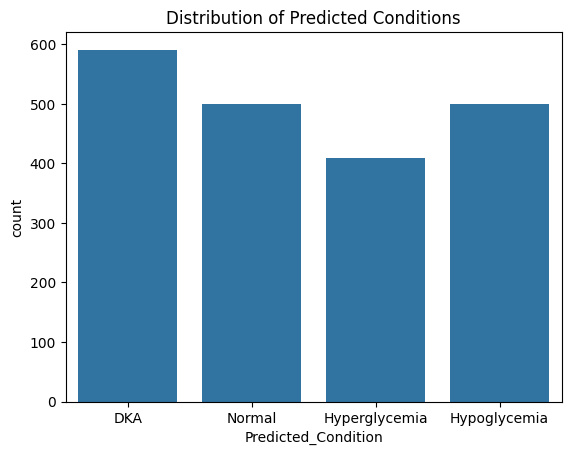

In [41]:

sns.countplot(x="Predicted_Condition", data=df_results)
plt.title("Distribution of Predicted Conditions")
plt.show()


Model Accuracy on Real Data: 0.9275

Classification Report:

               precision    recall  f1-score   support

          DKA       0.80      0.95      0.87       500
Hyperglycemia       0.93      0.76      0.84       500
 Hypoglycemia       1.00      1.00      1.00       500
       Normal       1.00      1.00      1.00       500

     accuracy                           0.93      2000
    macro avg       0.93      0.93      0.93      2000
 weighted avg       0.93      0.93      0.93      2000



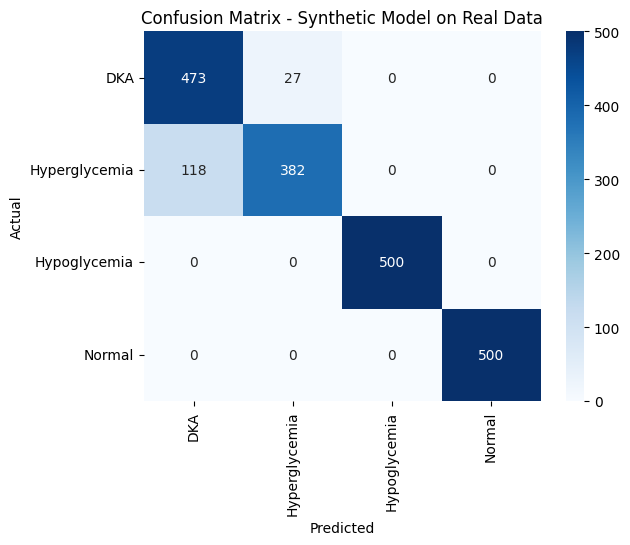

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Actual (true) labels
y_true = df["condition"]

# Predicted labels
y_pred = y_real_pred

# 1️⃣ Accuracy
print("Model Accuracy on Real Data:", accuracy_score(y_true, y_pred))

# 2️⃣ Detailed report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# 3️⃣ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Synthetic Model on Real Data')
plt.show()


In [43]:
import pickle
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)  # y_train exists in notebook

# Preprocessor can be None (already factorized)
preprocessor = None

# Create model package
model_package = {
    'model': model,  # your trained model in notebook
    'label_encoder': label_encoder,
    'preprocessor': preprocessor,
    'feature_names': list(X_train.columns),
    'conditions': label_encoder.classes_.tolist(),
    'model_version': '1.0',
    'trained_date': datetime.now().strftime('%Y-%m-%d'),
    'accuracy': 0.9275
}

# Save pickle
with open('diabetes_classifier_model.pkl', 'wb') as file:
    pickle.dump(model_package, file)

print("✓ Pickle file saved successfully!")


✓ Pickle file saved successfully!
